# 9. Building an Auction Draft Board

Part of the `nuclearff` [User Tutorial](https://nolmacdonald.github.io/nuclearff/tutorial/index.html) notebook series -- every notebook shares one running `./demo` directory and depends on the ones before it having already run. See [README.md](README.md) for the full run order. Run `08_valuation.ipynb` first.

`08_valuation.ipynb` covered VORP and tiers as standalone pieces. This notebook wires everything from Chapters 5 through 8 into one pipeline: Sleeper league settings -> real fantasy points -> a value estimate -> replacement level and VORP -> auction dollars -> a full report. This is the `nuclearff.pipeline.auction_board` module, and it's exactly what produces the auction board CSV, markdown report, and PNG tables. Mirrors the [Auction Draft Board](https://nolmacdonald.github.io/nuclearff/tutorial/09_auction_draft_board.html) docs page.

`NUCLEARFF REDRAFT` (`1367225133634191360`), this tutorial's running example everywhere else, runs a snake draft -- no auction budget to price against. This notebook uses a different real league on the same Sleeper account, `Freeman Forever League` (`1387966835797798912`), whose draft actually is an auction.

## The wiring, step by step

`build_auction_board` runs the whole pipeline in one call, but every step it wires together already exists on its own -- nothing here reimplements scoring, projection, replacement level, or the dollar conversion:

In [1]:
from nuclearff.pipeline import build_auction_board
from nuclearff.sleeper import SleeperClient

league_id = "1387966835797798912"
client = SleeperClient(cache_dir="./demo/data/cache")

board, context = build_auction_board(
    league_id,
    seasons=[2024, 2025],
    as_of_season=2026,
    client=client,
    baseline="vols",
)

print(context["league_name"], context["season"])
print(f"Budget: ${context['budget_per_team']}/team x {context['num_teams']} teams")
print("Players valued:", board.height)
print("In draft pool:", board.filter(board["in_draft_pool"]).height)

ScoringEngine has no mapping for 27 nonzero scoring key(s); these will not be counted toward fantasy points: blk_kick=2.0, def_pass_def=0.10000000149011612, def_st_fum_rec=2.0, def_st_td=6.0, def_td=6.0, fgm_0_19=3.0, fgm_20_29=3.0, fgm_30_39=3.0, fgm_40_49=3.0, fgm_50p=3.0, fgm_yds_over_30=0.10000000149011612, fgmiss=-1.0, fum_rec=2.0, fum_rec_td=6.0, int=2.0, pts_allow_0=9.0, pts_allow_1_6=6.0, pts_allow_21_27=-1.0, pts_allow_28_34=-2.0, pts_allow_35p=-5.0, pts_allow_7_13=3.0, sack=1.0, safe=2.0, st_td=6.0, tkl_loss=0.25, xpm=1.0, xpmiss=-1.0


Freeman Forever League 2026
Budget: $200/team x 10 teams
Players valued: 746
In draft pool: 140


Internally, `build_auction_board` did exactly this:

1. **League settings and budget** -- `league_config_from_sleeper` for scoring/roster shape, `budget_from_draft` for the per-team dollar amount, read straight from the Sleeper draft object.
2. **Realized points** -- `score_seasons`, the same `ScoringEngine` call from `05_scoring_engine.ipynb`, across every season in `seasons`.
3. **A value estimate** -- `project_points`, a recency-weighted average of those realized seasons (`07_projections.ipynb`'s idea, applied to whole-season point totals).
4. **Replacement level and VORP, per position** -- `add_vorp_all_positions`, one call per position instead of four (`08_valuation.ipynb`).
5. **Auction dollars** -- `auction_values` (below).
6. **A market comparison** -- FantasyPros consensus rankings, joined by `gsis_id`.

`value_estimate` is a **recency-weighted average of what players actually did**, not a forward projection. It carries no injury news, no depth-chart change, and a rookie with no prior season doesn't appear on the board at all -- the same caveat `07_projections.ipynb` states for `blend_projection`, because this is the exact same idea applied to realized points instead of one rate column.

## Auction dollars

`auction_values` is the dollar conversion on its own -- it distributes the league's spendable budget across the draftable pool in proportion to each player's share of total positive VORP:

In [2]:
top = board.sort("auction_value", descending=True).select(
    ["player_display_name", "position", "auction_value", "vorp", "rank_overall"]
)
top.head(6)

player_display_name,position,auction_value,vorp,rank_overall
str,str,f64,f64,i64
"""Jahmyr Gibbs""","""RB""",94.638172,171.562501,1
"""Bijan Robinson""","""RB""",90.367317,163.737502,2
"""Jonathan Taylor""","""RB""",77.643441,140.425001,3
"""Ja'Marr Chase""","""WR""",76.156146,137.700001,4
"""Derrick Henry""","""RB""",73.352118,132.562501,5
"""De'Von Achane""","""RB""",65.745082,118.625001,6


## Keeper cost adjustment

Keeper inflation is implemented but not wired into `build_auction_board` -- Sleeper exposes no keeper-price endpoint, so keeper costs must come from you. Given a `{player_id: cost}` mapping, `keeper_inflation_multiplier` returns the factor every non-kept dollar of value inflates by, and `keeper_adjusted_values` applies it:

In [3]:
from nuclearff.valuation.auction import (
    keeper_adjusted_values,
    keeper_inflation_multiplier,
)

top3_ids = board.sort("auction_value", descending=True).head(3)["player_id"].to_list()
keeper_costs = dict.fromkeys(top3_ids, 5.0)

multiplier = keeper_inflation_multiplier(
    board, keeper_costs, teams=10, budget_per_team=200
)
print(f"Inflation multiplier: {multiplier:.3f}")

adjusted = keeper_adjusted_values(board, keeper_costs, teams=10, budget_per_team=200)
adjusted.sort("auction_value", descending=True).select(
    ["player_display_name", "auction_value", "auction_value_keeper_adjusted"]
).head(4)

Inflation multiplier: 1.143


player_display_name,auction_value,auction_value_keeper_adjusted
str,f64,f64
"""Jahmyr Gibbs""",94.638172,5.0
"""Bijan Robinson""",90.367317,5.0
"""Jonathan Taylor""",77.643441,5.0
"""Ja'Marr Chase""",76.156146,87.011746


Kept players (illustrated here with a made-up $5 keeper cost for the top 3) show their real kept cost, not their market value; every *other* player's value inflates by the real multiplier printed above -- the market value those three keepers would otherwise have consumed still has to be spent by the other nine teams, on everyone else.

> **Why this matters:** the $5 keeper cost above is deliberately made up -- Sleeper has no keeper-price field to read, so this project correctly refuses to invent one. If your own league runs keepers, the real costs (whatever your league's actual keeper rule computes, e.g. "last auction price + $5") have to come from you, by hand, the same way this cell supplies them. That's a deliberate design choice, not a missing feature -- see the project's own decision notes if you're curious why.

## Writing the full report

`write_report` writes the CSV, one styled PNG table per position, and a markdown report with a methodology section -- everything `report auction-board` writes on the command line (`18_cli_reference.ipynb`), called directly:

In [4]:
from nuclearff.report import write_report

report_path = write_report(board, context, "./demo/data/artifacts", top_n=12)
report_path

PosixPath('demo/data/artifacts/report.md')

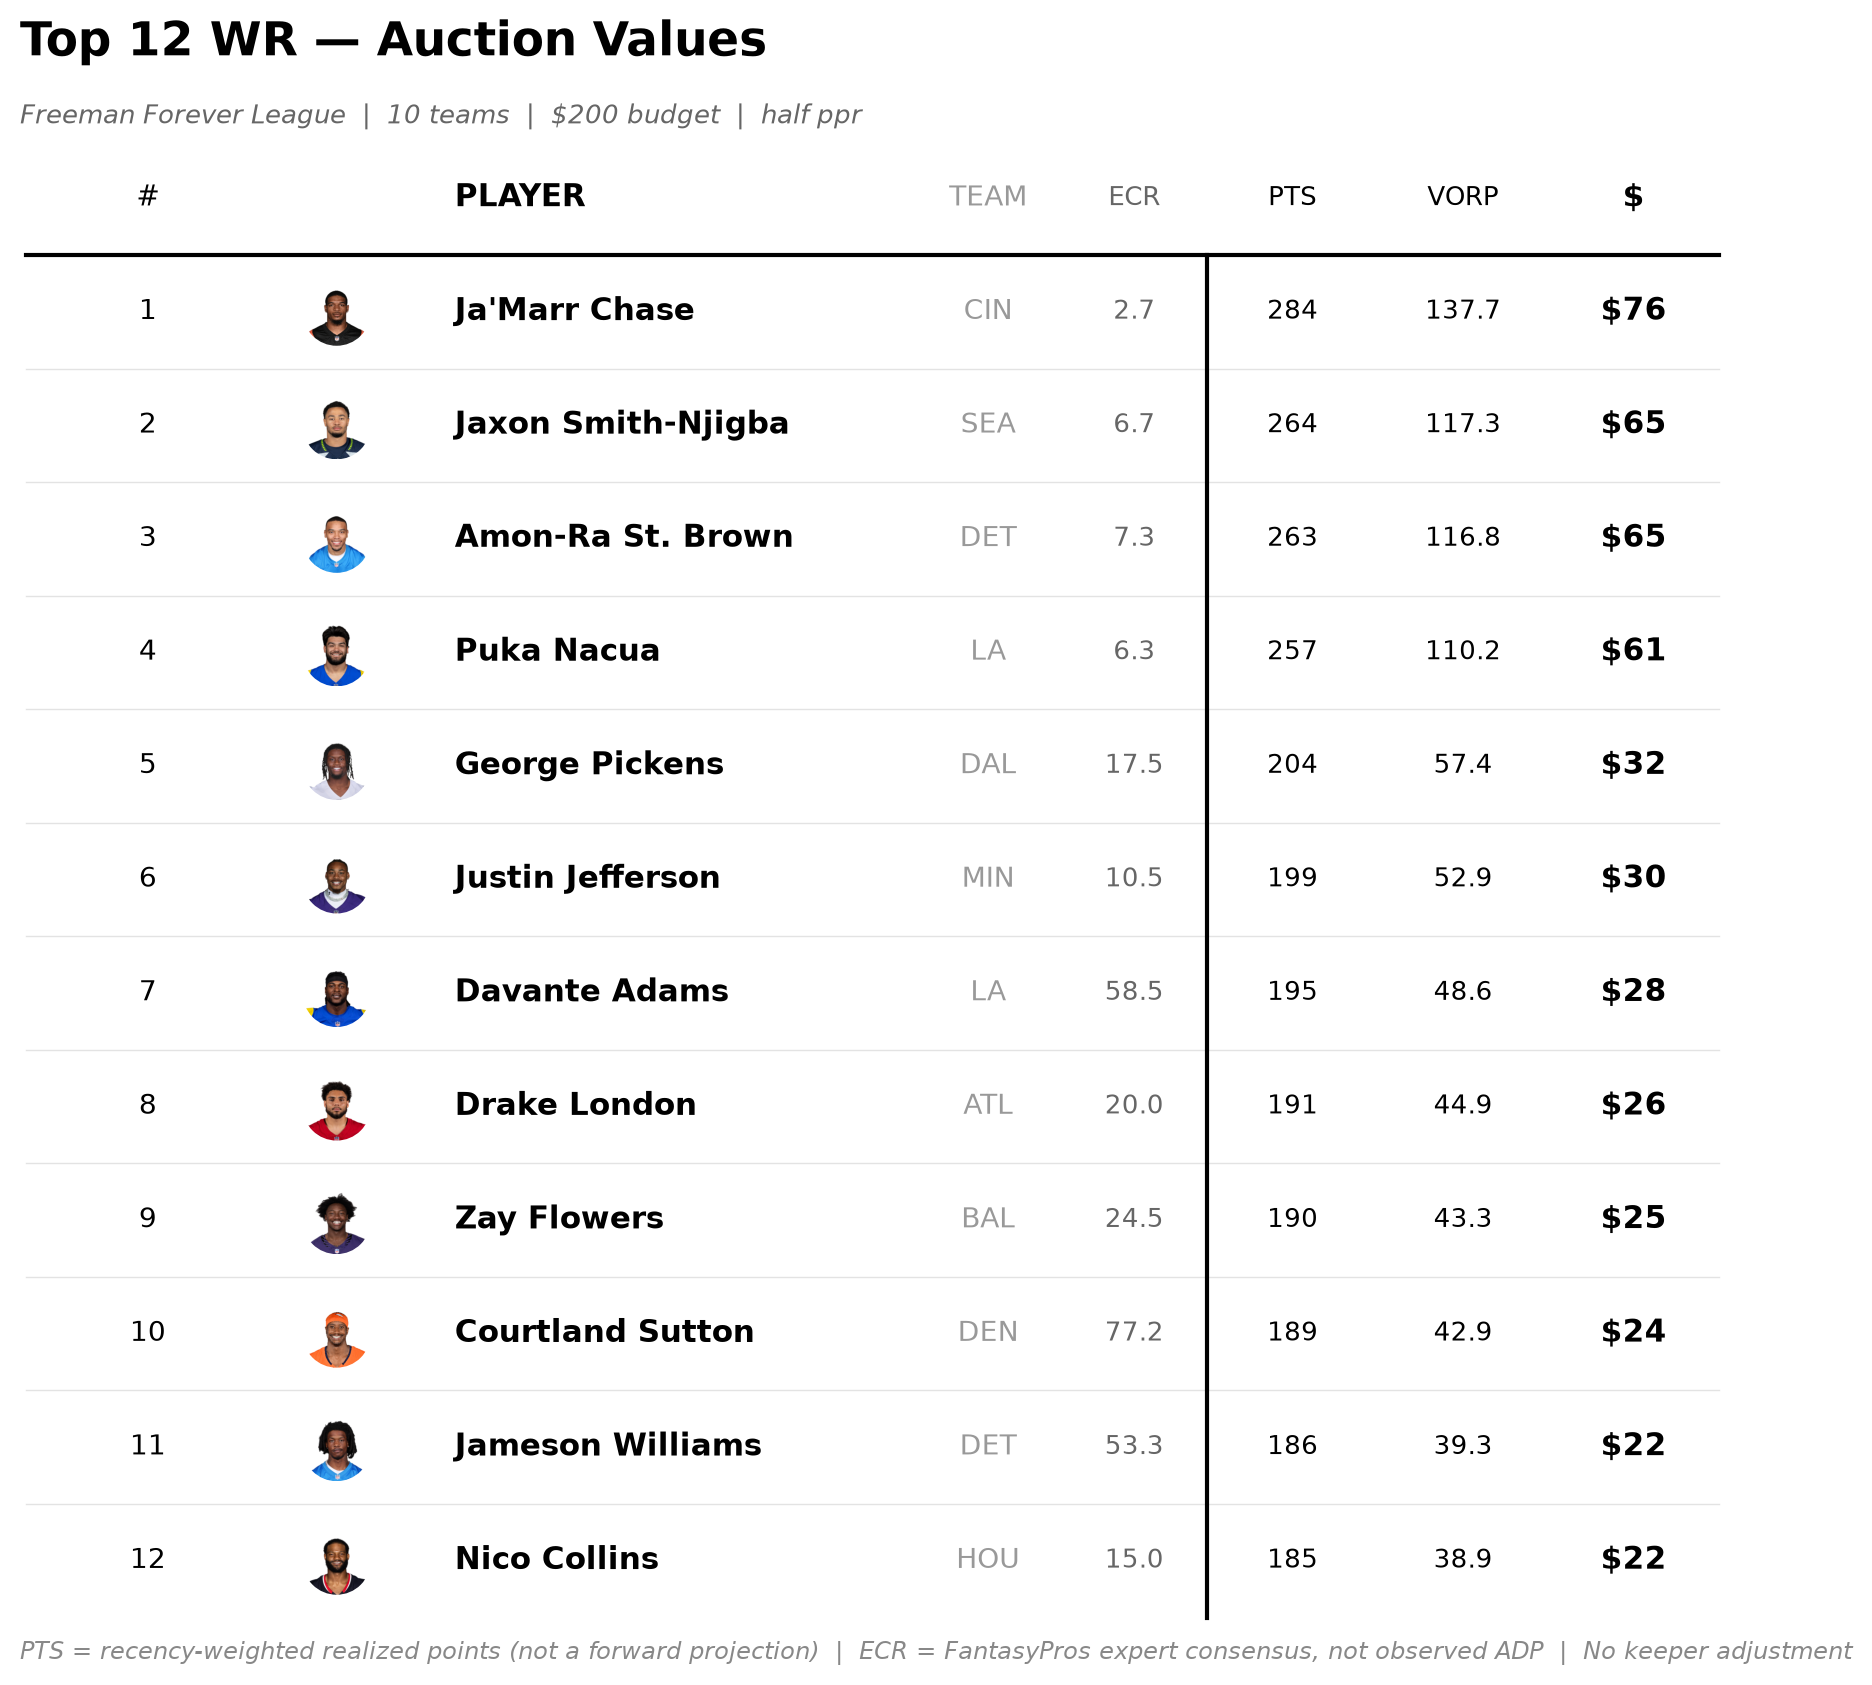

In [5]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/tables/top_12_wr.png")
)  # Styled auction-board table for the top 12 WRs

One of four position tables this call renders (QB, RB, WR, TE). Pass `render_tables=False` to skip these and avoid the `plottable`/`matplotlib` dev extra. The markdown report's methodology section states the same caveats as above in plain language.

## What's Next

An auction board values every player at once. `10_draft_and_playoff_visuals.ipynb` covers the complementary picture -- what actually happened in a specific draft or a specific season's playoffs, rendered as a grid or a bracket tree.

## See Also

- `08_valuation.ipynb` -- VORP and tiers on their own, before this chapter's pipeline wires them together.
- [Auction Draft Board](https://nolmacdonald.github.io/nuclearff/tutorial/09_auction_draft_board.html) -- the matching docs page.